# Statistical Analysis Notebook
**Goal**: Follow Demsar framework to provide fair and confident evaluation

## Build the per fold matrix

In [34]:
from pathlib import Path
import pandas as pd

PER_FOLD_CSV = Path("./results/pen-based_rerun_results.csv")  # <- change if different
if not PER_FOLD_CSV.exists():
    raise FileNotFoundError(f"Per-fold CSV not found: {PER_FOLD_CSV}")

df = pd.read_csv(PER_FOLD_CSV)

# required columns
need = [
    "dataset","metric","k","vote","retention",
    "fold_id","num_folds",
    "f1_macro"
]
missing = [c for c in need if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

# build config_ids
metric_code = {"euclidean": "e", "cosine": "c", "heom": "h"}
vote_code   = {"borda": "b", "modified_plurality": "mp"}
ret_code    = {
    "RetentionPolicy.ALWAYS_RETAIN": "AR",
    "RetentionPolicy.NEVER_RETAIN": "NR",
    "RetentionPolicy.DIFFERENT_CLASS_RETENTION": "DC",
    "RetentionPolicy.DD_RETENTION": "DD",
}

def short_config_id(row):
    m = metric_code.get(str(row["metric"]), str(row["metric"])[:2])
    v = vote_code.get(str(row["vote"]), str(row["vote"])[:2])
    r = ret_code.get(str(row["retention"]), str(row["retention"])[:2])
    return f"{m}-k{int(row['k'])}-{v}-{r}"

if "config_id" not in df.columns:
    df["config_id"] = df.apply(short_config_id, axis=1)

df
# Build the pivot matrix
pivot = df.pivot_table(index="fold_id", columns="config_id", values="f1_macro", aggfunc="mean")
pivot


config_id,c-k5-b-AR,c-k5-b-DC,c-k5-b-DD,c-k5-b-NR,e-k5-b-DC,e-k5-b-DD,e-k5-b-NR,h-k5-b-DC,h-k5-b-DD,h-k5-b-NR
fold_id,,,,,,,,,,
0,0.995401,0.994495,0.994495,0.994495,0.996278,0.996278,0.996278,0.996278,0.996278,0.996278
1,0.992807,0.992807,0.992807,0.992807,0.992807,0.992807,0.992807,0.992807,0.992807,0.992807
2,0.995364,0.994443,0.994443,0.994443,0.993529,0.993529,0.993529,0.993529,0.993529,0.993529
3,0.991832,0.991832,0.991832,0.991832,0.992784,0.992784,0.992784,0.992784,0.992784,0.992784
4,0.995433,0.995433,0.995433,0.995433,0.994485,0.994485,0.994485,0.994485,0.994485,0.994485
5,0.995431,0.995429,0.995429,0.995429,0.996308,0.996308,0.997218,0.996308,0.996308,0.997218
6,0.996371,0.995497,0.995497,0.995497,0.995464,0.994558,0.994558,0.995464,0.994558,0.994558
7,0.992922,0.992922,0.992922,0.992922,0.992922,0.992922,0.992922,0.992922,0.992922,0.992922
8,0.996349,0.996349,0.996349,0.996349,0.995438,0.995438,0.995438,0.995438,0.995438,0.995438


In [35]:
# rank within each fold
ranks = pivot.rank(axis=1, ascending=False, method="average")  # ties get average rank

# aggregate across folds
avg_rank = ranks.mean(axis=0)                 # average rank per config
mean_f1  = pivot.mean(axis=0)                 # mean F1 across folds 
std_f1   = pivot.std(axis=0, ddof=1)          # spread across folds
rank1_ct = (ranks == 1.0).sum(axis=0)         # how many times each config was rank 1

rank_table = (
    pd.DataFrame({
        "avg_rank": avg_rank,
        "mean_f1":  mean_f1,
        "std_f1":   std_f1,
        "rank1_count": rank1_ct,
    })
    .sort_values(["avg_rank","mean_f1"], ascending=[True, False])
)
rank_table

,avg_rank,mean_f1,std_f1,rank1_count
config_id,,,,
c-k5-b-AR,4.6,0.994466,0.001691,2
c-k5-b-DC,5.4,0.994196,0.001518,0
c-k5-b-DD,5.4,0.994196,0.001518,0
c-k5-b-NR,5.4,0.994196,0.001518,0
e-k5-b-NR,5.6,0.994277,0.001607,0
h-k5-b-NR,5.6,0.994277,0.001607,0
e-k5-b-DC,5.6,0.994277,0.001492,0
h-k5-b-DC,5.6,0.994277,0.001492,0
e-k5-b-DD,5.9,0.994186,0.001439,0


In [36]:
from scipy.stats import friedmanchisquare

pivot_f = pivot.dropna(axis=1, how="any")
alg_vectors = [pivot_f[c].values for c in pivot_f.columns]

stat, pval = friedmanchisquare(*alg_vectors)
print(f"Friedman test = {stat:.4f}, p = {pval:.6g}  (df = {pivot_f.shape[1]-1})")

Friedman test = 2.3684, p = 0.984215  (df = 9)


In [ ]:
import numpy as np
import pandas as pd
import scikit_posthocs as sp

# Drop any columns with NaN 
pivot_n = pivot.dropna(axis=1, how="any")

# Nemenyi posthoc on Friedman ranks
nemenyi_p = sp.posthoc_nemenyi_friedman(pivot_n.values)

# Add config labels to the matrix 
nemenyi_p.index = pivot_n.columns
nemenyi_p.columns = pivot_n.columns
    
print("Nemenyi post-hoc p-values (all vs all):")
display(nemenyi_p.round(4))

Nemenyi post-hoc p-values (all vs all):


config_id,c-k5-b-AR,c-k5-b-DC,c-k5-b-DD,c-k5-b-NR,e-k5-b-DC,e-k5-b-DD,e-k5-b-NR,h-k5-b-DC,h-k5-b-DD,h-k5-b-NR
config_id,,,,,,,,,,
c-k5-b-AR,1.0000,0.9999,0.9999,0.9999,0.9993,0.9943,0.9993,0.9993,0.9943,0.9993
c-k5-b-DC,0.9999,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
c-k5-b-DD,0.9999,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
c-k5-b-NR,0.9999,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
e-k5-b-DC,0.9993,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
e-k5-b-DD,0.9943,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
e-k5-b-NR,0.9993,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
h-k5-b-DC,0.9993,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
h-k5-b-DD,0.9943,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


Critical Difference (CD) at α=0.05: 4.284


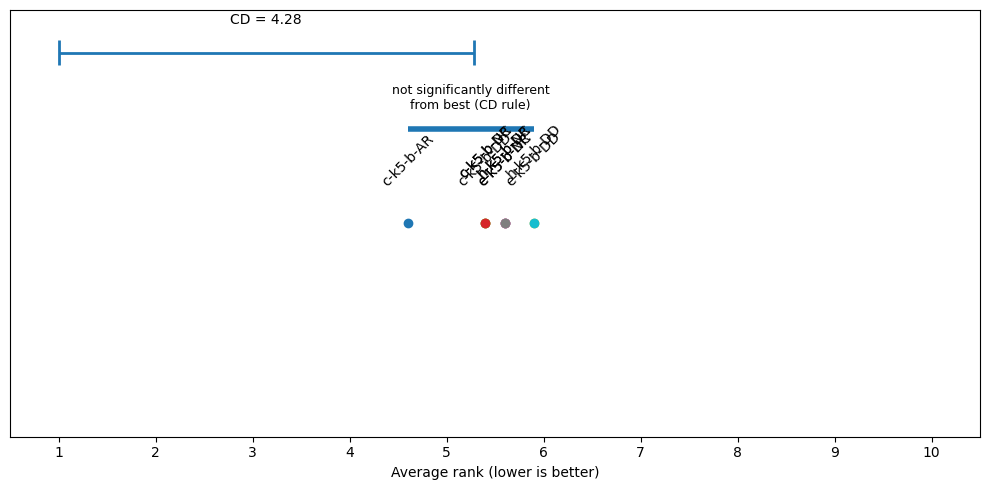

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# get k (configs) and N (folds)
k = len(rank_table)
N = pivot.shape[0]  # number of folds (datasets)

# Critical value for the two-tailed Nemenyi test
q_alpha = 3.164  # α=0.05, N=10

# compute CD
CD = q_alpha * np.sqrt(k * (k + 1) / (6.0 * N))
print(f"Critical Difference (CD) at α=0.05: {CD:.3f}")

# prepare data: average ranks sorted (lower is better)
avg = rank_table["avg_rank"].copy()
avg.sort_values(inplace=True)
labels = avg.index.tolist()
ranks = avg.values

# basic plot
fig, ax = plt.subplots(figsize=(10, 5))

# horizontal axis (ranks from 1 to k)
ax.set_xlim(1 - 0.5, k + 0.5)
ax.set_ylim(0, 1)
ax.get_yaxis().set_visible(False)
ax.set_xlabel("Average rank (lower is better)")

# tick marks at integer ranks
ax.set_xticks(np.arange(1, k+1, 1))

# plot points with labels
y0 = 0.5
for i, (lab, r) in enumerate(zip(labels, ranks)):
    ax.plot(r, y0, marker='o')
    ax.text(r, y0 + 0.08 + 0.02*(i%2), lab, rotation=45,
            ha='center', va='bottom')

# raw CD bar at the top-left of the axis
bar_y = 0.9
bar_x_left = 1.0
bar_x_right = 1.0 + CD
ax.hlines(bar_y, bar_x_left, bar_x_right, linewidth=2)
ax.vlines([bar_x_left, bar_x_right], bar_y - 0.03, bar_y + 0.03, linewidth=2)
ax.text((bar_x_left + bar_x_right)/2, bar_y + 0.06, f"CD = {CD:.2f}", ha='center', va='bottom')

# highlight configs within one CD of the best (left-most rank)
best_rank = ranks[0]
within_cd = [lab for lab, r in zip(labels, ranks) if (r - best_rank) <= CD]

# draw a connecting thick line for the non-significant group (vs best)
if len(within_cd) > 1:
    left = best_rank
    right = max(avg.loc[within_cd].values)
    ax.hlines(0.72, left, right, linewidth=4)
    ax.text((left + right)/2, 0.76, "not significantly different\nfrom best (CD rule)",
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()